# IBIM Forward Solver in Five Modular Steps

This notebook rewrites the repo's essential forward path in the five-step logic:

```text
phi(x, y)
  -> tubular region |phi| <= eps
  -> boundary points + normals + weights
  -> Muller_BIE(boundary, eps_in, eps_out, freq, source)
  -> receiver fields
```

The point is module wiring, not deriving every kernel. The repo fuses steps 2 and 3 inside `build_implicit_boundary_band(...)`; here we split them apart manually and then assert that the split version reproduces the repo helper.

## Cell 0 - Setup

Use the project environment that has `torch`, `numpy`, `scipy`, `matplotlib`, and `scikit-image` available. In this workspace, `EMNerf` is the tested environment.

In [12]:
from __future__ import annotations

import sys
from pathlib import Path
from types import SimpleNamespace


def find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "gpr_bem").is_dir() and (candidate / "config" / "simulation_config.py").is_file():
            return candidate
    raise RuntimeError("Could not find repo root containing gpr_bem/ and config/simulation_config.py")


repo_root = find_repo_root(Path.cwd().resolve())
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
loaded_config = sys.modules.get("config")
if loaded_config is not None and not str(getattr(loaded_config, "__file__", "")).startswith(str(repo_root)):
    del sys.modules["config"]

import matplotlib.pyplot as plt
import numpy as np
import torch
from scipy.special import hankel1

from config import simulation_config as cfg
from gpr_bem.ibim_geometry import (
    build_implicit_boundary_band,
    compress_implicit_boundary_band,
    regularized_cosine_delta,
)
from gpr_bem.ibim_tmz_forward import (
    implicit_double_layer_potential_from_band,
    implicit_single_layer_potential_from_band,
)
from gpr_bem.ibim_tmz_system import (
    build_ibim_tmz_frequency_system,
    ibim_incident_trace_on_boundary,
)
from gpr_bem.materials import Material
from gpr_bem.neural_sdf import SirenSDF2D, circle_signed_distance

torch.set_default_dtype(torch.float64)

device = torch.device("cpu")
dtype = torch.float64

bounds = ((0.0, 0.0), (float(cfg.DOMAIN_WIDTH), float(cfg.DOMAIN_HEIGHT)))
center = (float(cfg.TARGET_CENTER_X), float(cfg.TARGET_CENTER_Y))
radius = float(cfg.TARGET_RADIUS)

eps_out = float(cfg.SAND_EPSR)       # outside medium: sand
eps_in = float(cfg.PLASTIC_EPSR)     # inside medium: plastic/cylinder
frequency_hz = float(cfg.CENTER_FREQ)
omega = 2.0 * np.pi * frequency_hz

grid_shape = (257, 257)
grid_h = max(
    float(cfg.DOMAIN_WIDTH) / (grid_shape[1] - 1),
    float(cfg.DOMAIN_HEIGHT) / (grid_shape[0] - 1),
)
delta_half_width = 2.5 * grid_h
band_half_width = delta_half_width
merge_distance = 0.01
offset_distance = 0.04

print(sys.executable)
print(f"circle center={center}, radius={radius} m")
print(f"eps_out={eps_out}, eps_in={eps_in}, frequency={frequency_hz / 1e9:.2f} GHz")

/home/drdeng/miniconda3/envs/EMNerf/bin/python
circle center=(0.5, 0.5), radius=0.05 m
eps_out=6.0, eps_in=3.0, frequency=2.50 GHz


## Cell 1 - `phi(x, y)`

Module: `gpr_bem/neural_sdf.py`

For transparency, start with an analytic circle SDF. `SirenSDF2D` is a drop-in because it has the same signature: `model(points) -> (N, 1)`.

In [13]:
def phi(points: torch.Tensor) -> torch.Tensor:
    """Analytic circle SDF with the same call signature as SirenSDF2D."""

    return circle_signed_distance(points, center=center, radius=radius)


# Drop-in replacement shape, not used below:
siren_drop_in = SirenSDF2D(hidden_features=64, hidden_layers=2).to(device=device, dtype=dtype)

probe = torch.tensor(
    [[center[0], center[1]], [center[0] + radius, center[1]], [center[0] + 2.0 * radius, center[1]]],
    device=device,
    dtype=dtype,
)
print(phi(probe).detach().cpu().numpy().ravel())

[-5.00000000e-02  4.16333634e-17  5.00000000e-02]


## Cell 2 - Tubular Region `|phi| <= eps`

Module: `gpr_bem/ibim_geometry.py`

The grid is fixed. The SDF determines which grid samples are near the current interface. This is the modular replacement for marching squares in the repo's mainline IBIM path.

grid points: 66049
tubular samples: 408
h=(0.00391, 0.00391), cell_area=1.525879e-05


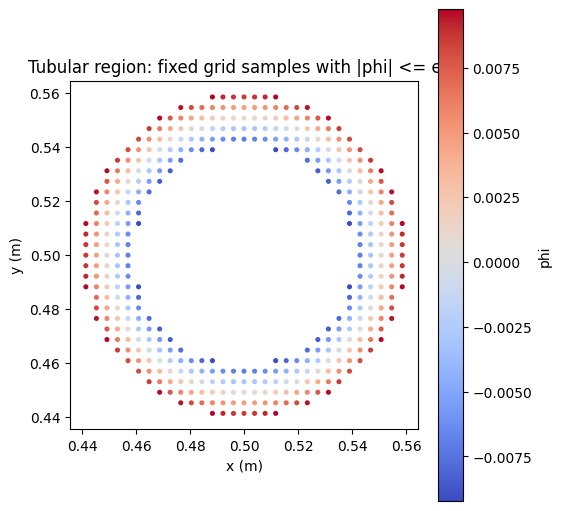

In [14]:
def cartesian_grid(bounds, grid_shape, *, device, dtype):
    (xmin, ymin), (xmax, ymax) = bounds
    ny, nx = grid_shape
    x = torch.linspace(xmin, xmax, nx, device=device, dtype=dtype)
    y = torch.linspace(ymin, ymax, ny, device=device, dtype=dtype)
    grid_y, grid_x = torch.meshgrid(y, x, indexing="ij")
    points = torch.stack((grid_x, grid_y), dim=-1).reshape(-1, 2)
    hx = float((xmax - xmin) / (nx - 1))
    hy = float((ymax - ymin) / (ny - 1))
    return grid_x, grid_y, points, (hx, hy), hx * hy


grid_x, grid_y, grid_points, spacing, cell_area = cartesian_grid(
    bounds,
    grid_shape,
    device=device,
    dtype=dtype,
)

points_for_grad = grid_points.detach().clone().requires_grad_(True)
phi_values = phi(points_for_grad)
grad_phi = torch.autograd.grad(
    outputs=phi_values,
    inputs=points_for_grad,
    grad_outputs=torch.ones_like(phi_values),
    create_graph=True,
    retain_graph=True,
    only_inputs=True,
)[0]

band_mask = torch.abs(phi_values[:, 0]) <= band_half_width
band_grid_points = points_for_grad[band_mask]
band_phi = phi_values[band_mask]
band_grad_phi = grad_phi[band_mask]

print(f"grid points: {grid_points.shape[0]}")
print(f"tubular samples: {band_grid_points.shape[0]}")
print(f"h=({spacing[0]:.5f}, {spacing[1]:.5f}), cell_area={cell_area:.6e}")

fig, ax = plt.subplots(figsize=(5.5, 5.0), constrained_layout=True)
sc = ax.scatter(
    band_grid_points[:, 0].detach().cpu(),
    band_grid_points[:, 1].detach().cpu(),
    c=band_phi[:, 0].detach().cpu(),
    s=7,
    cmap="coolwarm",
)
ax.set_aspect("equal")
ax.set_title("Tubular region: fixed grid samples with |phi| <= eps")
ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")
plt.colorbar(sc, ax=ax, label="phi")
plt.show()

## Cell 3 - Boundary Points, Normals, Weights

Module: `gpr_bem/ibim_geometry.py`

This cell performs the split-out version of what `build_implicit_boundary_band(...)` normally does:

```text
n = grad(phi) / |grad(phi)|
p = y - (phi / |grad(phi)|) n
w = delta_eps(phi) |grad(phi)| h^2
J = 1 - tau kappa
w_strict = w J
```

The diagnostic `sum(w) ~ 2 pi R` is the fastest sanity check that the implicit boundary quadrature is sane.

split geometry matches build_implicit_boundary_band(...)
sum(w)        = 0.31412515 m
sum(w_strict) = 0.31418165 m
2*pi*R        = 0.31415927 m
mean |grad phi| in band = 1.00000000
mean curvature in band  = 19.79973474; exact 1/R = 20.00000000


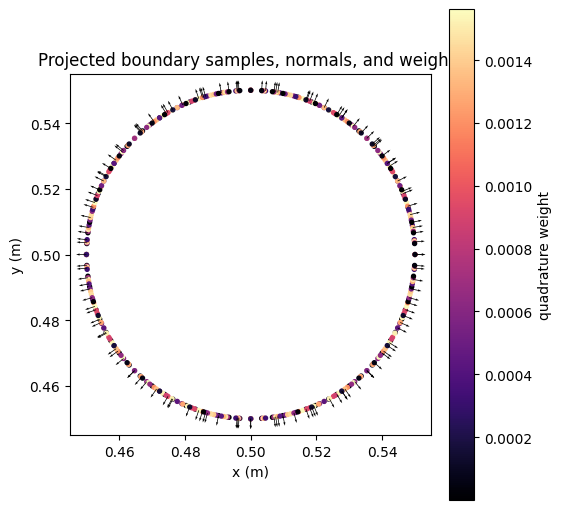

In [15]:
def divergence_of_vector_field(vector_field: torch.Tensor, points: torch.Tensor) -> torch.Tensor:
    terms = []
    for axis in range(2):
        derivative = torch.autograd.grad(
            outputs=vector_field[:, axis],
            inputs=points,
            grad_outputs=torch.ones_like(vector_field[:, axis]),
            create_graph=False,
            retain_graph=True,
            only_inputs=True,
        )[0][:, axis : axis + 1]
        terms.append(derivative)
    return terms[0] + terms[1]


gradient_epsilon = 1.0e-8
grad_norm_all = torch.linalg.norm(grad_phi, dim=1, keepdim=True).clamp_min(gradient_epsilon)
grad_norm = grad_norm_all[band_mask]
normals = band_grad_phi / grad_norm
signed_offset = band_phi / grad_norm
projected_points = band_grid_points - signed_offset * normals

normals_all = grad_phi / grad_norm_all
curvature_all = divergence_of_vector_field(normals_all, points_for_grad)
curvature = curvature_all[band_mask]
jacobian = 1.0 - signed_offset * curvature

delta_values = regularized_cosine_delta(band_phi, delta_half_width)
quadrature_weights = delta_values * grad_norm * float(cell_area)
strict_quadrature_weights = quadrature_weights * jacobian

repo_band = build_implicit_boundary_band(
    phi,
    bounds,
    grid_shape=grid_shape,
    band_half_width=band_half_width,
    delta_half_width=delta_half_width,
    device=device,
    dtype=dtype,
)

torch.testing.assert_close(projected_points.detach(), repo_band.projected_points, rtol=1.0e-12, atol=1.0e-12)
torch.testing.assert_close(normals.detach(), repo_band.normals, rtol=1.0e-12, atol=1.0e-12)
torch.testing.assert_close(quadrature_weights.detach(), repo_band.quadrature_weights, rtol=1.0e-12, atol=1.0e-12)
torch.testing.assert_close(strict_quadrature_weights.detach(), repo_band.strict_quadrature_weights, rtol=1.0e-12, atol=1.0e-12)

perimeter_exact = 2.0 * np.pi * radius
measure = float(quadrature_weights.sum().detach().cpu())
measure_strict = float(strict_quadrature_weights.sum().detach().cpu())

print("split geometry matches build_implicit_boundary_band(...)")
print(f"sum(w)        = {measure:.8f} m")
print(f"sum(w_strict) = {measure_strict:.8f} m")
print(f"2*pi*R        = {perimeter_exact:.8f} m")
print(f"mean |grad phi| in band = {float(grad_norm.mean().detach().cpu()):.8f}")
print(f"mean curvature in band  = {float(curvature.mean().detach().cpu()):.8f}; exact 1/R = {1.0 / radius:.8f}")

fig, ax = plt.subplots(figsize=(5.5, 5.0), constrained_layout=True)
p = projected_points.detach().cpu().numpy()
n = normals.detach().cpu().numpy()
w = quadrature_weights[:, 0].detach().cpu().numpy()
stride = max(p.shape[0] // 120, 1)
sc = ax.scatter(p[:, 0], p[:, 1], c=w, s=8, cmap="magma")
ax.quiver(p[::stride, 0], p[::stride, 1], n[::stride, 0], n[::stride, 1], scale=35, width=0.002)
ax.set_aspect("equal")
ax.set_title("Projected boundary samples, normals, and weights")
ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")
plt.colorbar(sc, ax=ax, label="quadrature weight")
plt.show()

In [16]:
# Forward runs usually use the compressed sample representation.
# This is a forward/cache step: it uses rounding + unique bins, so do not treat it as a smooth map.
boundary = compress_implicit_boundary_band(repo_band, merge_distance=merge_distance)

print(f"uncompressed boundary samples: {repo_band.num_samples}")
print(f"compressed boundary samples:   {boundary.num_samples}")
print(f"compressed sum(w):             {float(boundary.boundary_measure().detach().cpu()):.8f} m")
print(f"compressed sum(w_strict):      {float(boundary.boundary_measure(strict=True).detach().cpu()):.8f} m")

uncompressed boundary samples: 408
compressed boundary samples:   136
compressed sum(w):             0.31412515 m
compressed sum(w_strict):      0.31418165 m


## Cell 4 - `Muller_BIE(...)`

Modules: `gpr_bem/ibim_tmz_forward.py` and `gpr_bem/ibim_tmz_system.py`

For now, treat this as a module boundary. This cell takes the geometric boundary object from Cell 3 plus source/material/frequency data, and returns the solved boundary traces. Receiver evaluation is Cell 5.

### Input contract

```text
boundary.points              p_j, projected points on phi=0, shape (N, 2)
boundary.normals             n_j, outward normals, shape (N, 2)
boundary.quadrature_weights  w_j, ds weights, shape (N, 1)
eps_out                      exterior relative permittivity -> k_out
eps_in                       interior relative permittivity -> k_in
frequency_hz                 frequency f -> omega = 2*pi*f
source_point                 transmitter/source location
source_strength              complex source amplitude
```

### Output contract

```text
bie_solution.dirichlet_incident   incident E_z trace on boundary, b_D
bie_solution.neumann_incident     incident normal derivative trace, b_N
bie_solution.dirichlet_total      solved total E_z trace on boundary, u_D
bie_solution.neumann_total        solved total normal derivative trace, u_N
bie_solution.system               assembled operator system and k_out/k_in
```

Internally, the repo does this:

```text
boundary samples + material + frequency + source
  -> assemble V, K, K', W by offset-average traces
  -> assemble the TMz/Muller-like block system
  -> solve for boundary Dirichlet/Neumann traces u_D, u_N
```

The repo's readable default is the offset-average trick: evaluate traces at `p +/- d n` and average. No new quadrature math is introduced in this notebook.

The final diagnostic compares the direct `Aq=b` solve with the repo's `A^2 q = A b` solve. In exact arithmetic these are equivalent when `A` is invertible; in the current offset-average discretization this is a conditioning diagnostic, not a correctness assertion.

In [ ]:
def helmholtz_green_2d(k: complex, r: np.ndarray) -> np.ndarray:
    """Only here as a readable reminder of the kernel behind the module."""

    return 0.25j * hankel1(0, complex(k) * r)


def muller_bie(
    boundary,
    eps_in: float,
    eps_out: float,
    frequency_hz: float,
    source_point: np.ndarray,
    receiver_points: np.ndarray,
    *,
    source_strength: complex = 1.0 + 0.0j,
    offset_distance = None,
    use_strict_quadrature: bool = False,
    backend: str = "numpy",
):
    """Thin wrapper that exposes the repo solver with the five-step signature."""

    receiver_array = np.asarray(receiver_points, dtype=float)
    source = np.asarray(source_point, dtype=float).reshape(1, 2)

    # The repo forward API is paired Tx/Rx. For one source and many receivers,
    # repeat the source so each receiver has a paired source row.
    source_array = np.repeat(source, receiver_array.shape[0], axis=0)

    return solve_ibim_tmz_total_field_batch(
        boundary,
        source_array,
        receiver_array,
        2.0 * np.pi * float(frequency_hz),
        complex(source_strength),
        exterior=Material(epsr=float(eps_out), sigma=0.0),
        interior=Material(epsr=float(eps_in), sigma=0.0),
        eps0=float(cfg.EPS0),
        mu0=float(cfg.MU0),
        offset_distance=offset_distance,
        use_strict_quadrature=use_strict_quadrature,
        backend=backend,
    )


num_receivers = 72
angles = np.linspace(0.0, 2.0 * np.pi, num_receivers, endpoint=False)
receiver_radius = 0.22
receiver_points = np.column_stack(
    (
        center[0] + receiver_radius * np.cos(angles),
        center[1] + receiver_radius * np.sin(angles),
    )
)
source_point = np.array([0.20, 0.20], dtype=float)

forward = muller_bie(
    boundary,
    eps_in,
    eps_out,
    frequency_hz,
    source_point,
    receiver_points,
    source_strength=1.0 + 0.0j,
    offset_distance=offset_distance,
    use_strict_quadrature=False,
    backend="numpy",
)

print("Muller_BIE input quantities")
print(f"boundary.points:             {tuple(boundary.points.shape)}  projected phi=0 samples p_j")
print(f"boundary.normals:            {tuple(boundary.normals.shape)}  outward normals n_j")
print(f"boundary.quadrature_weights: {tuple(boundary.quadrature_weights.shape)}  ds weights w_j")
print(f"eps_out -> k_out:            {eps_out:.2f} -> {forward.system.k_exterior:.4e}")
print(f"eps_in  -> k_in:             {eps_in:.2f} -> {forward.system.k_interior:.4e}")
print(f"source points passed:        {forward.source_points.shape}")
print(f"receiver points passed:      {forward.receiver_points.shape}")

print("\nMuller_BIE output quantities")
print(f"dirichlet_incident b_D:      {forward.dirichlet_incident.shape}")
print(f"neumann_incident b_N:        {forward.neumann_incident.shape}")
print(f"dirichlet_total u_D:         {forward.dirichlet_total.shape}")
print(f"neumann_total u_N:           {forward.neumann_total.shape}")
print(f"incident_receiver:           {forward.incident_receiver.shape}")
print(f"single_receiver S_r u_N:     {forward.single_receiver.shape}")
print(f"double_receiver D_r u_D:     {forward.double_receiver.shape}")
print(f"scattered_receiver:          {forward.scattered_receiver.shape}")
print(f"total_receiver:              {forward.total_receiver.shape}")

A = np.asarray(forward.system.system_matrix[0], dtype=np.complex128)
rhs = np.concatenate((forward.dirichlet_incident, forward.neumann_incident), axis=1).T
q_unsquared = np.linalg.solve(A, rhs)
q_squared = np.linalg.solve(A @ A, A @ rhs)
relative_q_difference = np.linalg.norm(q_unsquared - q_squared) / max(np.linalg.norm(q_unsquared), 1.0e-30)
direct_residual = np.linalg.norm(A @ q_unsquared - rhs) / max(np.linalg.norm(rhs), 1.0e-30)
squared_as_direct_residual = np.linalg.norm(A @ q_squared - rhs) / max(np.linalg.norm(rhs), 1.0e-30)
squared_residual = np.linalg.norm((A @ A) @ q_squared - A @ rhs) / max(np.linalg.norm(A @ rhs), 1.0e-30)

print(f"boundary samples N: {forward.system.num_boundary_samples}")
print(f"system shape:       {A.shape}")
print(f"offset distance:    {forward.system.offset_distance:.5f} m")
print(f"cond(A):            {np.linalg.cond(A):.3e}")
print(f"cond(A @ A):        {np.linalg.cond(A @ A):.3e}")
print(f"Aq=b vs A^2q=Ab relative q difference: {relative_q_difference:.3e}")
print(f"direct residual ||Aq-b||/||b|| for Aq=b:      {direct_residual:.3e}")
print(f"direct residual ||Aq-b||/||b|| for A^2 solve: {squared_as_direct_residual:.3e}")
print(f"squared residual for repo solve:               {squared_residual:.3e}")

Muller_BIE input quantities
boundary.points:             (136, 2)  projected phi=0 samples p_j
boundary.normals:            (136, 2)  outward normals n_j
boundary.quadrature_weights: (136, 1)  ds weights w_j
eps_out -> k_out:            6.00 -> 1.2834e+02+0.0000e+00j
eps_in  -> k_in:             3.00 -> 9.0753e+01+0.0000e+00j
source points passed:        (72, 2)
receiver points passed:      (72, 2)

Muller_BIE output quantities
dirichlet_incident b_D:      (72, 136)
neumann_incident b_N:        (72, 136)
dirichlet_total u_D:         (72, 136)
neumann_total u_N:           (72, 136)
incident_receiver:           (72,)
single_receiver S_r u_N:     (72,)
double_receiver D_r u_D:     (72,)
scattered_receiver:          (72,)
total_receiver:              (72,)
boundary samples N: 136
system shape:       (272, 272)
offset distance:    0.04000 m
cond(A):            9.050e+21
cond(A @ A):        1.391e+22
Aq=b vs A^2q=Ab relative q difference: 1.000e+00
direct residual ||Aq-b||/||b|| for Aq=b:   

## Cell 5 - Receiver Fields

Module boundary:

```text
boundary traces from Cell 4
  -> E_inc(receiver)
  -> D_r u_D - S_r u_N
  -> E_total(receiver)
```

The lower-level single/double receiver rows live in `ibim_tmz_forward.py`; `solve_ibim_tmz_total_field_batch(...)` already returns the separated pieces.

receiver field arrays
incident_receiver:  (72,)
single_receiver:    (72,)
double_receiver:    (72,)
scattered_receiver: (72,)
total_receiver:     (72,)


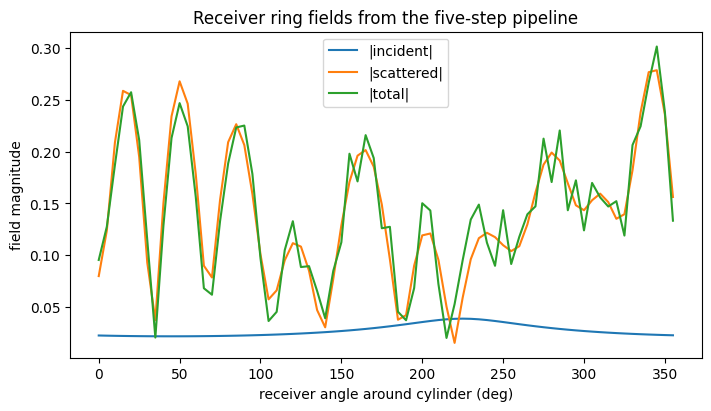

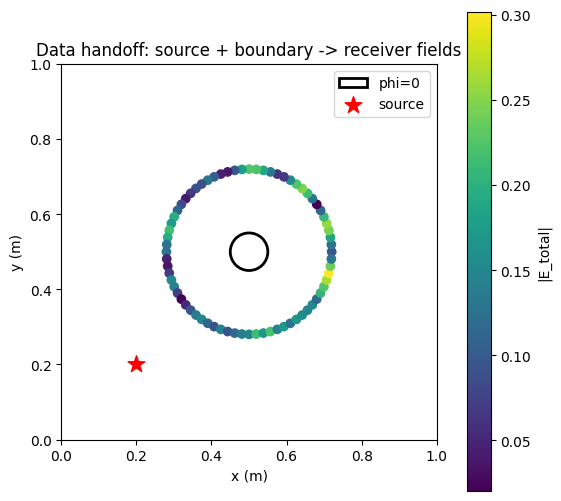

In [18]:
print("receiver field arrays")
print(f"incident_receiver:  {forward.incident_receiver.shape}")
print(f"single_receiver:    {forward.single_receiver.shape}")
print(f"double_receiver:    {forward.double_receiver.shape}")
print(f"scattered_receiver: {forward.scattered_receiver.shape}")
print(f"total_receiver:     {forward.total_receiver.shape}")

fig, ax = plt.subplots(figsize=(7.0, 4.0), constrained_layout=True)
ax.plot(np.degrees(angles), np.abs(forward.incident_receiver), label="|incident|")
ax.plot(np.degrees(angles), np.abs(forward.scattered_receiver), label="|scattered|")
ax.plot(np.degrees(angles), np.abs(forward.total_receiver), label="|total|")
ax.set_xlabel("receiver angle around cylinder (deg)")
ax.set_ylabel("field magnitude")
ax.set_title("Receiver ring fields from the five-step pipeline")
ax.legend()
plt.show()

fig, ax = plt.subplots(figsize=(5.5, 5.0), constrained_layout=True)
circle = plt.Circle(center, radius, fill=False, color="black", linewidth=2, label="phi=0")
ax.add_patch(circle)
sc = ax.scatter(receiver_points[:, 0], receiver_points[:, 1], c=np.abs(forward.total_receiver), cmap="viridis")
ax.scatter([source_point[0]], [source_point[1]], marker="*", s=160, c="red", label="source")
ax.set_aspect("equal")
ax.set_xlim(0.0, 1.0)
ax.set_ylim(0.0, 1.0)
ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")
ax.set_title("Data handoff: source + boundary -> receiver fields")
ax.legend(loc="upper right")
plt.colorbar(sc, ax=ax, label="|E_total|")
plt.show()

## Where the Adjoint Attaches

This notebook stops at the forward field. The inverse/adjoint path attaches after Cell 5:

```text
receiver residual
  -> adjoint solve in ibim_tmz_adjoint.py
  -> leading-order normal shape gradient on boundary samples
  -> shape_gradient_surrogate_loss(...)
  -> SirenSDF2D parameter update
```

Structural seam to remember:

```text
geometry: torch/autograd
BIE assembly/solve: numpy or cupy
gradient bridge: explicit adjoint / shape-gradient surrogate
```

That seam is intentional in the current repo design and is the main reason the modules are arranged this way.